# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE)

## Notebook P2-07: UBFC-rPPG Ensemble rPPG Extraction

### What this notebook does

Extracts rPPG signals from all 42 UBFC-rPPG subjects using a **three-algorithm ensemble** (POS, CHROM, GREEN) producing `ubfc-rppg_ensemble.h5` with a schemia compatible with `mcd_rppg_ensemble`.


### Key differences from NB_P2_06 (MCD-rPPG)

| Aspect | MCD-rPPG (NB06) | UBFC-rPPG (this notebook) |
|--------|-----------------|---------------------------|
| Reference | ECG (500Hz JSON) + PPG (.PW) | BVP signal only (ground_truth.txt Row 0) |
| HR ground truth | PPG peaks -> hr_continuous | Pre-computed per-frame HR (GT Row 1) - direct |
| Timestamps | Derived from PPG timestamps | GT Row 2 (seconds) |
| ECG SQI | 1 - CV(RR_ECG) | Not available -> PPG SQI: 1 - CV(RR_BVP) |
| Biomarkers | 13 clinical biomarkers | None (not collected) |
| Sessions | before / after (exercise) | Single session: 'rest' |
| Subjects | 600 | 42 |
| FPS | 29.9 Hz | Subject-specific (~23.2 or ~29.x Hz) |
| HRV | ECG R-peaks | BVP peaks (less accurate but consistent) |



### Pipeline

```
subject_N/vid.avi + ground_truth.txt
    │
    ├─ 1  BGR -> RGB
    ├─ 2  MediaPipe Face Mesh -> ROI masks (forehead, left cheek, right cheek)
    └─ 3  Spatial mean RGB per ROI -> roi_rgb [T, 3_ROIs, 3_ch]
               │
               ├─ 4a  POS algorithm  -> rppg_pos [T]
               ├─ 4b  CHROM algorithm -> rppg_chrom [T]
               └─ 4c  GREEN mean  -> rppg_green [T]
                         │
                         ├─ 5  Bandpass 0.7–3.5 Hz + z-score (all three)
                         ├─ 6  Spectral SQI: peak/band power ratio (all three)
                         └─ 7  Quality-weighted ensemble -> rppg_ensemble [T]

ground_truth.txt:
  Row 0 (BVP) -> bandpass -> peaks -> rr_intervals + HRV + ppg_sqi
  Row 1 (HR) -> clip to [40–200] BPM -> hr_continuous [T]
  Row 2 (time) -> fps verification

 8  Gate: ppg_sqi >= 0.3 AND ensemble_sqi >= 0.07
 9  Write to ubfc_rppg_ensemble.h5
```

### SQI gate rationale

UBFC-rPPG has no ECG. PPG SQI (`1 - CV(RR_BVP)`) replaces ECG SQI.
Threshold 0.3 is conservative given the clean lab conditions of UBFC-rPPG.
Ensemble SQI threshold 0.07 — same calibration as MCD-rPPG NB06 (spectral peak-to-band ratio, ±3 bins).

### Skip conditions

- `flat_bvp` - BVP amplitude < 0.1 (sensor failure)
- `ppg_sqi_low` - PPG SQI < 0.3 (poor reference quality)
- `implausible_hr` -mean HR outside 40–200 BPM
- `no_face` - > 20% frames without face detection
- `ensemble_sqi_low` - ensemble spectral SQI < 0.07
- `too_short` - fewer than 240 frames (cannot form even one window)

## 1. Environment Setup

In [1]:
import subprocess, sys

packages = [
    "neurokit2",
    "mediapipe",
    "h5py",
    "opencv-python",
    "scipy",
    "numpy",
    "pandas",
    "matplotlib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages confirmed.")

All packages confirmed.


## 2. Imports

In [2]:
import os, warnings, cv2, h5py, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from pathlib import Path
from scipy.signal import butter, filtfilt
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color"  : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})

DATASET_ROOT = "F:/UBFC-rPPG"  
OUTPUT_DIR = "E:/QualityPhys"

print(f"Dataset root : {DATASET_ROOT}")
print(f"Output dir : {OUTPUT_DIR}")

Dataset root : F:/UBFC-rPPG
Output dir : E:/QualityPhys


## 3. Configuration

In [3]:
DATASET_NAME = "ubfc_rppg_ensemble"
HDF5_PATH = os.path.join(OUTPUT_DIR, "ubfc_rppg_ensemble.h5")
MP_MODEL_PATH = os.path.join(OUTPUT_DIR, "face_landmarker.task")

# Single session per subject
SESSION_ID = "rest"
SESSION_NAME = "controlled_rest"

# Signal processing — identical to NB06
RPPG_BP_LOW, RPPG_BP_HIGH = 0.7, 3.5
BVP_BP_LOW, BVP_BP_HIGH  = 0.5, 8.0
BUTTER_ORDER = 4

# SQI gates
# Ensemble SQI: same spectral peak-to-band threshold as NB06
RPPG_SQI_THRESHOLD = 0.07
RPPG_SQI_MIN_FLOOR = 0.01   # weight floor for ensemble computation
# PPG SQI replaces ECG SQI (no ECG available in UBFC-rPPG)
# Threshold 0.3: UBFC-rPPG is lab-controlled, expect clean BVP
PPG_SQI_THRESHOLD  = 0.3

# Face detection
NO_FACE_THRESHOLD = 20.0  

# HR physiological limits
HR_MIN = 40
HR_MAX = 200

# HR continuity: per-frame HR values below this are treated as invalid
# (ground truth sometimes has near-zero values at recording start)
HR_FRAME_VALID_MIN = 40.0
HR_FRAME_VALID_MAX = 200.0

# Algorithms
ALGORITHMS = ["pos", "chrom", "green"]

# HDF5 skip key
HDF5_SKIP_KEY = "rppg_ensemble"

# ROI landmark indices — identical to NB06
FOREHEAD_LM = [10,338,297,332,284,251,389,356,454,
               323,361,288,397,365,379,378,400,377,
               152,148,176,149,150,136,172,58,132,
               93,234,127,162,21,54,103,67,109]
LEFT_CHEEK_LM = [234,227,116,123,147,213,192,214,210,
                 211,206,203,36,101,119,229,228]

RIGHT_CHEEK_LM = [454,447,345,352,376,433,416,434,430,
                  431,426,423,266,330,348,449,448]

ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM,
}

print("UBFC-rPPG configuration loaded.")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Session : {SESSION_ID} ({SESSION_NAME})")
print(f"rPPG band : {RPPG_BP_LOW}–{RPPG_BP_HIGH} Hz")
print(f"Algorithms : {ALGORITHMS}")
print(f"Ensemble SQI >= : {RPPG_SQI_THRESHOLD}")
print(f"PPG SQI >= : {PPG_SQI_THRESHOLD}")
print(f"HR valid range : {HR_MIN}-{HR_MAX} BPM")
print(f"No-face threshold : {NO_FACE_THRESHOLD}%")

UBFC-rPPG configuration loaded.
Output HDF5 : E:/QualityPhys\ubfc_rppg_ensemble.h5
Session : rest (controlled_rest)
rPPG band : 0.7–3.5 Hz
Algorithms : ['pos', 'chrom', 'green']
Ensemble SQI >= : 0.07
PPG SQI >= : 0.3
HR valid range : 40-200 BPM
No-face threshold : 20.0%


## 4. Build Recording Inventory

In [4]:
def build_inventory(dataset_root: str) -> pd.DataFrame:
    """
    Scan dataset_root for subject folders.
    Each subject folder must contain vid.avi (or .mp4) and ground_truth.txt.
    Checks HDF5 for already-completed subjects to enable resume.
    """
    root = Path(dataset_root)
    records = []

    for subject_dir in sorted(root.iterdir()):
        if not subject_dir.is_dir():
            continue

        subject_name = subject_dir.name

        # Find video
        video_path = None
        for ext in [".avi", ".mp4"]:
            candidates = list(subject_dir.glob(f"*{ext}"))
            if candidates:
                video_path = str(candidates[0])
                break

        # Find GT
        gt_candidates = list(subject_dir.glob("*.txt"))
        gt_path = str(gt_candidates[0]) if gt_candidates else None

        has_video = video_path is not None and os.path.exists(video_path)
        has_gt = gt_path is not None and os.path.exists(gt_path)

        # Read FPS from video header
        fps = 29.9 # fallback
        n_frames_video = 0
        if has_video:
            cap = cv2.VideoCapture(video_path)
            fps_header = cap.get(cv2.CAP_PROP_FPS)
            n_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            cap.release()
            if fps_header > 0:
                fps = fps_header

        records.append({
            "subject_name" : subject_name,
            "video_path" : video_path,
            "gt_path" : gt_path,
            "has_video" : has_video,
            "has_gt" : has_gt,
            "fps" : fps,
            "n_frames_video" : n_frames_video
        })

    df = pd.DataFrame(records).sort_values("subject_name").reset_index(drop=True)

    # Mark already-done subjects 
    df["done"] = False
    if os.path.exists(HDF5_PATH):
        with h5py.File(HDF5_PATH, "r") as hf:
            for i, row in df.iterrows():
                hdf5_key = f"subjects/{row['subject_name']}/recordings/{SESSION_ID}"
                if hdf5_key in hf:
                    df.at[i, "done"] = True
    return df


df_inventory = build_inventory(DATASET_ROOT)

print(f"Total subjects : {len(df_inventory)}")
print(f"Videos found : {df_inventory['has_video'].sum()}")
print(f"GT files found : {df_inventory['has_gt'].sum()}")
print(f"Already done : {df_inventory['done'].sum()}")
print(f"Remaining : {(df_inventory['has_video'] & df_inventory['has_gt'] & ~df_inventory['done']).sum()}")
print()
print("FPS distribution:")
fps_bins = pd.cut(df_inventory["fps"], bins=[22, 24, 29, 31], labels=["~23 fps", "~29 fps", "~30 fps"])
print(fps_bins.value_counts().sort_index())
print()
print(df_inventory[["subject_name","fps","n_frames_video","has_video","has_gt","done"]].to_string())

Total subjects : 42
Videos found : 42
GT files found : 42
Already done : 0
Remaining : 42

FPS distribution:
fps
~23 fps     3
~29 fps     2
~30 fps    37
Name: count, dtype: int64

   subject_name        fps  n_frames_video  has_video  has_gt   done
0      subject1  29.264106            1547       True    True  False
1     subject10  29.875482            2024       True    True  False
2     subject11  29.700708            2031       True    True  False
3     subject12  29.029684            1989       True    True  False
4     subject13  29.790300            2018       True    True  False
5     subject14  29.371997            1993       True    True  False
6     subject15  29.590537            2020       True    True  False
7     subject16  29.931836            2050       True    True  False
8     subject17  29.932847            2046       True    True  False
9     subject18  29.747793            2034       True    True  False
10    subject20  29.505479            2016       True    Tr

## 5. Reference Signal Loaders

In [5]:
def load_ground_truth(gt_path: str) -> dict | None:
    """
    Parse UBFC-rPPG ground_truth.txt
    
    Confirmed formad:
        Row 0: BVP signal (n_frames floats, normalised, ~-2 to +3)
        Row 1: HR per frame (BPM, e.g. 60-130)
        Row 2: timestamps (seconds from 0)
        
    Returns dict with:
        bvp : np.ndarray [T] - raw BVP waveform
        hr_frames : np.ndarray [T] - per-frame HR in BPM
        timestamps : np.ndarray [T] - seconds
        gt_fps : float - FPS derived from timestamps
        n_frames : int
    """
    if not gt_path or not os.path.exists(gt_path):
        return None
    try:
        with open(gt_path, "r") as file:
            raw = file.read()

        lines = raw.strip().split("\n")
        if len(lines) < 3:
            print(f"[WARN] {gt_path}: expected 3 rows, got {len(lines)}")
            return None

        bvp = np.array([float(x) for x in lines[0].split()], dtype=np.float32)
        hr_frames = np.array([float(x) for x in lines[1].split()], dtype=np.float32)
        timestamps = np.array([float(x) for x in lines[2].split()], dtype=np.float64)

        # FPS from timestamps 
        if len(timestamps) > 1:
            dt = np.diff(timestamps).mean()
            gt_fps = float(1.0 / dt) if dt > 0 else 29.9
        else:
            gt_fps = 29.9

        return {
            "bvp" : bvp,
            "hr_frames" : hr_frames,
            "timestamps" : timestamps,
            "gt_fps" : gt_fps,
            "n_frames" : len(bvp),
        }

    except Exception as e:
        print(f"[WARN] GT parse error {gt_path}: {e}")
        return None



def clean_hr_continuous(hr_frames: np.ndarray) -> np.ndarray:
    """
    Per-frame HR cleaning:
    1. Replace values outside [HR_FRAME_VALID_MIN, HR_FRAME_VALID_MAX] with NaN.
       (Subject11 has min=1.0 BPM at recording start — clearly invalid.)
    2. Forward-fill NaN from first valid value.
    3. Backward-fill any remaining NaN at the start.
    Returns float32 array — may still contain NaN if entire signal is invalid.
    """
    hr = hr_frames.copy().astype(np.float32)
    hr[(hr < HR_FRAME_VALID_MIN) | (hr > HR_FRAME_VALID_MAX)] = np.nan

    # Forward fill
    last_valid = np.nan
    for i in range(len(hr)):
        if not np.isnan(hr[i]):
            last_valid = hr[i]
        elif not np.isnan(last_valid):
            hr[i] = last_valid

    # Backward fill leading NaNs
    first_valid = np.nan
    for i in range(len(hr) - 1, -1, -1):
        if not np.isnan(hr[i]):
            first_valid = hr[i]
        elif not np.isnan(first_valid):
            hr[i] = first_valid

    return hr


def compute_bvp_peaks(bvp: np.ndarray, fps: float) -> tuple:
    """
    Bandpass BVP -> nk.ppg_clean -> nk.ppg_peaks.
    Returns (peak_idx, rr_ms, hr_mean_bpm).
    Used for HRV computation and PPG SQI.
    """
    try:
        b, a = butter(BUTTER_ORDER, [BVP_BP_LOW / (fps / 2), BVP_BP_HIGH / (fps / 2)], btype="band")
        bvp_filt = filtfilt(b, a, bvp).astype(np.float32)
        bvp_clean = nk.ppg_clean(bvp_filt, sampling_rate=int(round(fps)))
        peak_dict, _ = nk.ppg_peaks(bvp_clean, sampling_rate=int(round(fps)))
        peak_idx = np.where(peak_dict["PPG_Peaks"] == 1)[0]

        if len(peak_idx) < 3:
            return peak_idx, np.array([]), float("nan")

        rr_ms = np.diff(peak_idx) / fps * 1000.0
        hr_mean = float(60000.0 / rr_ms.mean())
        return peak_idx, rr_ms, hr_mean

    except Exception as e:
        print(f"[WARN] BVP peak detection failed: {e}")
        return np.array([]), np.array([]), float("nan")



def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """Time domain HRV from RR intervals."""
    nan_result = {
        "mean_rr_ms": float("nan"), 
        "sdnn_ms": float("nan"),
        "rmssd_ms": float("nan"), 
        "pnn50_pct": float("nan")
    }

    if len(rr_ms) < 3:
        return nan_result
    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return nan_result
    diff = np.diff(rr)
    return {
        "mean_rr_ms": float(rr.mean()), 
        "sdnn_ms": float(rr.std()),
        "rmssd_ms": float(np.sqrt(np.mean(diff ** 2))), 
        "pnn50_pct": float((np.abs(diff) > 50).mean() * 100),
    }



def compute_ppg_sqi(rr_ms: np.ndarray) -> float:
    """
    PPG_SQI = 1 - CV(RR), analogous to ECG SQI in NB06,
    CV = std / mean. Range [0, 1].
    Higher = more regular heartbeat = better reference quality.
    """
    if len(rr_ms) < 3:
        return float("nan")
    rr = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]
    if len(rr) < 3:
        return float("nan")
    cv = rr.std() / (rr.mean() + 1e-8)
    return float(1.0 - min(cv, 1.0))


print("Ground truth loader and reference functions defined.")
print("Sanity check on first subject:")
test_row = df_inventory[df_inventory["has_gt"]].iloc[0]
gt = load_ground_truth(test_row["gt_path"])
if gt:
    hr_clean = clean_hr_continuous(gt["hr_frames"])
    _, rr, hr_mean = compute_bvp_peaks(gt["bvp"], gt["gt_fps"])
    hrv = compute_hrv_features(rr)
    ppg_sqi = compute_ppg_sqi(rr)
    print(f"Subject : {test_row['subject_name']}")
    print(f"BVP : n={len(gt['bvp'])}, min={gt['bvp'].min():.3f}, max={gt['bvp'].max():.3f}")
    print(f"HR frames : n={len(gt['hr_frames'])}, raw min={gt['hr_frames'].min():.1f}, raw max={gt['hr_frames'].max():.1f}")
    print(f"HR cleaned : min={np.nanmin(hr_clean):.1f}, max={np.nanmax(hr_clean):.1f}, NaN={np.sum(np.isnan(hr_clean))}")
    print(f"GT FPS : {gt['gt_fps']:.3f} Hz")
    print(f"BVP peaks : RR mean={rr.mean():.1f} ms, HR={hr_mean:.1f} BPM")
    print(f"HRV : RMSSD={hrv['rmssd_ms']:.1f} ms, SDNN={hrv['sdnn_ms']:.1f} ms")
    print(f"PPG SQI : {ppg_sqi:.3f}")

Ground truth loader and reference functions defined.
Sanity check on first subject:
Subject : subject1
BVP : n=1547, min=-1.705, max=2.783
HR frames : n=1547, raw min=97.0, raw max=113.0
HR cleaned : min=97.0, max=113.0, NaN=0
GT FPS : 29.341 Hz
BVP peaks : RR mean=566.3 ms, HR=106.0 BPM
HRV : RMSSD=86.6 ms, SDNN=60.8 ms
PPG SQI : 0.893


## 6. MediaPipe ROI Extraction

In [6]:
# Download MediaPipe face landmarker model if not present
if not os.path.exists(MP_MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MP_MODEL_PATH)
    print("Downloaded.")
else:
    print(f"Face landmarker model present: {MP_MODEL_PATH}")



def get_roi_mask(landmarks, frame_shape: tuple, lm_indices: list) -> np.ndarray:
    """Binary polygon mask for one ROI from MediaPipe landmarks."""
    h, w = frame_shape[:2]
    pts  = np.array([[int(landmarks[i].x * w), int(landmarks[i].y * h)] for i in lm_indices], dtype=np.int32)
    mask = np.zeros((h,w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask



def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Single-pass video extraction.
    Returns:
        roi_rgb : [T, n_rois, 3] spatially-averaged RGB per ROI
        actual_fps : float,
        n_frames : int, 
        no_face_pct : float - % frames without face detection
    """
    cap = cv2.VideoCapture(video_path)
    actual_fps = cap.get(cv2.CAP_PROP_FPS)
    if actual_fps <= 0:
        actual_fps = 29.9

    roi_names = list(roi_configs.keys())
    roi_sigs = {name : [] for name in roi_names}
    n_frames = 0
    no_face = 0

    base_opts = mp_python.BaseOptions(model_asset_path=MP_MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_opts,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            ts_ms = int((n_frames / actual_fps) * 1000)
            result = landmarker.detect_for_video(mp_img, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb.shape, indices)
                    if mask.sum() > 0:
                        r = rgb[:, :, 0][mask == 1].mean()
                        g = rgb[:, :, 1][mask == 1].mean()
                        b = rgb[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r,g,b], dtype=np.float32))
                    else:
                        fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fb)
            else:
                no_face += 1
                for name in roi_configs:
                    fb = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fb)

            n_frames += 1

    cap.release()

    arrays = [np.array(roi_sigs[name]) for name in roi_names]
    roi_rgb = np.stack(arrays, axis=1).astype(np.float32) # [T, n_rois, 3]

    return {
        "roi_rgb" : roi_rgb,
        "actual_fps" : actual_fps,
        "n_frames" : n_frames,
        "no_face_pct" : round(100 * no_face / max(n_frames, 1), 1)
    }


print("ROI extraction function defined")                        

Face landmarker model present: E:/QualityPhys\face_landmarker.task
ROI extraction function defined


## 7. rPPG Algorithms + Spectral SQI + Ensemble

In [7]:
def bandpass_filter(signal: np.ndarray, fps: float, low: float, high: float, order: int = 4) -> np.ndarray:
    """Zero-phase Butterworth bandpass."""
    nyq = fps / 2.0
    b,a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)



def zscore(signal: np.ndarray) -> np.ndarray:
    """Zero-mean unit-variance normalisation."""
    mu, sigma = signal.mean(), signal.std() + 1e-8
    return((signal - mu) / sigma).astype(np.float32)



def apply_pos(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """POS algorithm
    Projects normalised chrominance onto plane orthogonal to skin-tone vector.

    For each ROI independently, then average:
        Cn = C / mean(C) (temporal normalisation)
        S = P @ Cn.T (project to orthogonal plane)
        h = S[0] + alpha * S[1] 
    """
    P = np.array([[0, 1, -1], [-2, 1, 1]], dtype=np.float64)
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h  = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)
    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH)
    return zscore(filtered)


def apply_chrom(roi_rgb: np.ndarray, fps: float) -> np.ndarray:
    """
    CHROM algorithm
    Models skin reflectance as linear mixture of specular + diffuse components.

    For each ROI:
        Cn = C / mean(C) (temporal normalisation)
        Xs = 3*R - 2*G (chrominance 1)
        Ys = 1.5*R + G - 1.5*B (chrominance 2)
        H = Xs - alpha * Ys (alpha = std(xs)/std(ys) cancels specular)

    Strenghts: specular glare rejection.
    Known limitation: documented MAE degradation on darker skin tones.
    """
    n_rois = roi_rgb.shape[1]
    signals = []
    for r in range(n_rois):
        C = roi_rgb[:, r, :].astype(np.float64) # [T, 3]
        Cn = C / (C.mean(axis=0) + 1e-8)
        Xs = 3.0 * Cn[:,0] - 2.0 * Cn[:, 1]
        Ys = 1.5 * Cn[:, 0] + Cn[:, 1] - 1.5 * Cn[:, 2]
        alpha = Xs.std() / (Ys.std() + 1e-8)
        signals.append(Xs - alpha * Ys)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, fps, RPPG_BP_LOW, RPPG_BP_HIGH)
    return zscore(filtered)



def apply_green(roi_rgb: np.ndarray, fps:float) -> np.ndarray:
    """
    GREEN channel mean across ROIs.
    Physiological basis: oxyhaemoglobin absorption peak ~550 nm (green).
    No artefact rejection - interpretable performance floor / baseline.
    """
    green = roi_rgb[:, :, 1].mean(axis=1) # [T] - mean green across ROIs
    filtered = bandpass_filter(green, fps, RPPG_BP_LOW, RPPG_BP_HIGH)
    return zscore(filtered)


ALGORITHM_FN = {"pos": apply_pos, "chrom": apply_chrom, "green": apply_green}


def compute_spectral_sqi(signal: np.ndarray, fps: float) -> float:
    """
    Peak-to-band power ratio in cardiac band [0.7-3.5 Hz].

    SQI = P_dominant_peak / P_band_total

    Interpretation: 
        A periodic cardiac signal concentrates power at one dominant frequency.
        SQI -> 1.0: near-sinusoidal (very clean).
        SQI -> 0.1: power spread across the cardiac band (noisy but detectable).
        SQI -> 0.0: no dominant peak (noise).

    """
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1.0 / fps)
    power = np.abs(np.fft.rfft(signal - signal.mean())) ** 2

    mask = (freqs >= RPPG_BP_LOW) & (freqs <= RPPG_BP_HIGH)
    band_power = power[mask]

    if band_power.sum() < 1e-10:
        return 0.0

    peak_idx = np.argmax(band_power)
    low = max(0, peak_idx - 3)
    high = min(len(band_power), peak_idx + 4)
    peak_power = band_power[low:high].sum()

    return float(peak_power / band_power.sum())



def compute_ensemble(signals: dict, sqis: dict) -> tuple:
    """
    Quality-proportional weighted sum of z-scored rPPG signals.

    w_i = max(SQI_i, RPPG_SQI_MIN_FLOOR) / sum(w_j)

    The floor prevents division-by-zero when all SQI values are near zero.
    A floored weight means even a very weak algorithm contributes minimally
    rather than being hard-excluded.

    Returns: 
        ensemble : np.ndarray [T]
        weights : np.ndarray [n_alorithms] (sums ot 1)
    """
    raw_weights = np.array([max(sqis[alg], RPPG_SQI_MIN_FLOOR) for alg in ALGORITHMS], dtype=np.float64)
    weights = raw_weights / raw_weights.sum()

    stacked = np.stack([signals[alg] for alg in ALGORITHMS], axis=0) # [3, T]
    ensemble = (stacked * weights[:, None]).sum(axis=0).astype(np.float32)

    return ensemble, weights.astype(np.float32)


print("RPPG algorithm + SQI + ensemble functions defined.")
print(f"Algorithms : {ALGORITHMS}")

RPPG algorithm + SQI + ensemble functions defined.
Algorithms : ['pos', 'chrom', 'green']


## 8. Single-Subject Pipeline

Reference signal = BVP from ground_truth.txt Row 0. hr_continuous = cleaned per-frame HR from GT Row 1 (no reconstruction needed).

In [8]:
def process_single_subject(row: pd.Series, max_frames: int = None) -> tuple:
    """
    Full pipeline for one UBFC-rPPG subject.
    Returns (result_dict, status_string).
    result_dict is None if subject is skipped.
    """
    subject = row["subject_name"]

    #  Step 1: Load and validate ground truth 
    gt = load_ground_truth(row["gt_path"])
    if gt is None:
        return None, "gt_load_failed"

    bvp = gt["bvp"]
    gt_fps = gt["gt_fps"]

    if bvp.max() - bvp.min() < 0.1:
        return None, "flat_bvp"

    if len(bvp) < 240:
        return None, f"too_short ({len(bvp)} frames)"

    # Step 2: BVP peak detection → HRV + PPG SQI
    _, rr_ms, hr_mean_bvp = compute_bvp_peaks(bvp, gt_fps)

    if np.isnan(hr_mean_bvp) or hr_mean_bvp < HR_MIN or hr_mean_bvp > HR_MAX:
        return None, f"implausible_hr ({hr_mean_bvp:.1f} BPM)"

    ppg_sqi = compute_ppg_sqi(rr_ms)
    if not np.isnan(ppg_sqi) and ppg_sqi < PPG_SQI_THRESHOLD:
        return None, f"ppg_sqi_low ({ppg_sqi:.3f})"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: Clean hr_continuous from GT Row 1 
    hr_continuous_clean  = clean_hr_continuous(gt["hr_frames"])
    hr_mean = float(np.nanmean(hr_continuous_clean)) if not np.all(np.isnan(hr_continuous_clean)) else hr_mean_bvp

    # Step 4: ROI extraction from video 
    roi_out = extract_roi_signals(row["video_path"], ROI_CONFIGS, max_frames=max_frames)
    roi_rgb = roi_out["roi_rgb"]
    n_frames = roi_out["n_frames"]
    actual_fps = roi_out["actual_fps"]
    no_face = roi_out["no_face_pct"]

    if no_face > NO_FACE_THRESHOLD:
        return None, f"no_face ({no_face:.1f}%)"

    #  Step 5: Three rPPG algorithms 
    rppg_signals = {}
    rppg_sqis = {}
    for alg in ALGORITHMS:
        sig = ALGORITHM_FN[alg](roi_rgb, actual_fps)
        rppg_signals[alg] = sig
        rppg_sqis[alg] = compute_spectral_sqi(sig, actual_fps)

    # Step 6: Ensemble 
    rppg_ensemble, ens_weights = compute_ensemble(rppg_signals, rppg_sqis)
    sqi_ensemble = compute_spectral_sqi(rppg_ensemble, actual_fps)

    if sqi_ensemble < RPPG_SQI_THRESHOLD:
        return None, f"ensemble_sqi_low ({sqi_ensemble:.3f})"

    # Step 7: Align signals to shortest common length
    if abs(gt_fps - actual_fps) > 0.5:
        n_target = n_frames
        bvp_rs = np.interp(
            np.linspace(0, 1, n_target),
            np.linspace(0, 1, len(bvp)), bvp).astype(np.float32)
        hr_cont_rs = np.interp(
            np.linspace(0, 1, n_target),
            np.linspace(0, 1, len(hr_continuous_clean)),
            hr_continuous_clean).astype(np.float32)
    else:
        bvp_rs = bvp
        hr_cont_rs = hr_continuous_clean

    T = min(n_frames,
            len(rppg_ensemble),
            len(hr_cont_rs),
            len(bvp_rs),
            roi_rgb.shape[0])

    rppg_pos_s = rppg_signals["pos"][:T]
    rppg_chrom_s = rppg_signals["chrom"][:T]
    rppg_green_s = rppg_signals["green"][:T]
    rppg_ens_s = rppg_ensemble[:T]
    roi_rgb_s = roi_rgb[:T]
    hr_cont_s = hr_cont_rs[:T]
    ref_signal_s = bvp_rs[:T]
    rr_storage = rr_ms.astype(np.float32) if len(rr_ms) > 0 else np.array([], dtype=np.float32)

    sqis_str = " ".join(f"{a}={rppg_sqis[a]:.3f}" for a in ALGORITHMS)
    print(f"{subject} T={T} HR={hr_mean:.1f} ppg_sqi={ppg_sqi:.3f} ens={sqi_ensemble:.3f} [{sqis_str}] no_face={no_face:.1f}% fps={actual_fps:.2f}")

    result = {
        # rPPG signals
        "rppg_pos" : rppg_pos_s,
        "rppg_chrom" : rppg_chrom_s,
        "rppg_green" : rppg_green_s,
        "rppg_ensemble" : rppg_ens_s,
        "ensemble_weights" : ens_weights,
        # Supporting signals
        "roi_rgb" : roi_rgb_s,
        "reference_signal" : ref_signal_s,
        "hr_continuous" : hr_cont_s,
        "rr_intervals" : rr_storage,
        # Scalar labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],
        # SQI
        "ppg_sqi" : float(ppg_sqi) if not np.isnan(ppg_sqi) else -1.0,
        "sqi_pos" : float(rppg_sqis["pos"]),
        "sqi_chrom" : float(rppg_sqis["chrom"]),
        "sqi_green" : float(rppg_sqis["green"]),
        "sqi_ensemble" : float(sqi_ensemble),
        # Metadata
        "subject_id" : subject,
        "activity_id" : SESSION_ID,
        "activity_name" : SESSION_NAME,
        "dataset" : DATASET_NAME,
        "reference_type" : "BVP_continuous",
        "n_frames" : T,
        "fps" : actual_fps,
        "no_face_pct" : float(no_face),
    }
    return result, "ok"


print("process_single_subject defined.")

process_single_subject defined.


## 9. Single-Subject Demo (300 frames)

In [9]:
# demo_row = df_inventory[df_inventory["has_video"] & df_inventory["has_gt"]].iloc[0]
# print(f"Demo: {demo_row['subject_name']} | fps={demo_row['fps']:.3f}")
# print()

# demo_result, demo_reason = process_single_subject(demo_row, max_frames=300)

# if demo_result is not None:
#     print()
#     print("Signal shapes:")
#     for key in ["rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals", "ensemble_weights"]:
#         arr = demo_result.get(key)
#         if arr is not None and hasattr(arr, "shape"):
#             nan_c = int(np.sum(np.isnan(arr.astype(float)))) if arr.dtype != object else 0
#             print(f" {key:<22} : {arr.shape} dtype={arr.dtype} nan={nan_c}")
#     print()
#     print("Scalar labels:")
#     for key in ["hr_mean", "rmssd_ms", "sdnn_ms", "pnn50_pct", "ppg_sqi", "sqi_ensemble", "no_face_pct", "fps", "n_frames"]:
#         print(f" {key:<20} : {demo_result[key]}")

#     # Quick signal plot
#     fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
#     T = len(demo_result["rppg_ensemble"])
#     t = np.arange(T) / demo_result["fps"]

#     axes[0].plot(t, demo_result["reference_signal"], color="#74b9ff", lw=0.8)
#     axes[0].set_title(f"BVP reference - {demo_row['subject_name']} (first 300 frames)")
#     axes[0].set_ylabel("amplitude")

#     axes[1].plot(t, demo_result["rppg_pos"], color="#55efc4", lw=0.8, label="POS")
#     axes[1].plot(t, demo_result["rppg_chrom"], color="#fd79a8", lw=0.8, label="CHROM")
#     axes[1].plot(t, demo_result["rppg_green"], color="#fdcb6e", lw=0.8, label="GREEN")
#     axes[1].set_title("Individual rPPG signals")
#     axes[1].set_ylabel("z-score")
#     axes[1].legend(fontsize=8)

#     axes[2].plot(t, demo_result["rppg_ensemble"], color="#a29bfe", lw=1.0)
#     w = demo_result["ensemble_weights"]
#     axes[2].set_title(f"Ensemble (w_pos={w[0]:.2f} w_chrom={w[1]:.2f} w_green={w[2]:.2f})")
#     axes[2].set_ylabel("amplitude")

#     axes[3].plot(t, demo_result["hr_continuous"], color="#e17055", lw=0.8)
#     axes[3].set_title(f"hr_continuous (GT Row 1 cleaned) - mean={demo_result['hr_mean']:.1f} BPM")
#     axes[3].set_ylabel("BPM")
#     axes[3].set_xlabel("time (s)")

#     plt.suptitle(f"UBFC-rPPG Demo - {demo_row['subject_name']}", fontsize=12)
#     plt.tight_layout()
#     plt.savefig(os.path.join(OUTPUT_DIR, "ubfc_rppg_demo.png"), dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
#     plt.show()
# else:
#     print(f"Demo subject skipped: {demo_reason}")

## 10. HDF5 Write Functions

In [11]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> bool:
    """
    Write one UBFC-rPPG subject/session to HDF5.
    Path: subjects/{subject_name}/recordings/{SESSION_ID}/

    Resume-safe: skips if group already exists.
    """
    subj = result["subject_id"] # e.g. "subject1"
    state = result["activity_id"] # "rest"
    path = f"subjects/{subj}/recordings/{state}"

    if path in h5_file:
        return False

    grp = h5_file.require_group(path)

    # Signal datasets
    for ds_name in [
        "rppg_pos", "rppg_chrom", "rppg_green", "rppg_ensemble", "ensemble_weights", "roi_rgb", "reference_signal", "hr_continuous", "rr_intervals"]:
        grp.create_dataset(ds_name, data=result[ds_name], compression="gzip", compression_opts=4)

    # Standard scalar attributes
    std_attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"])  else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "ppg_sqi" : result["ppg_sqi"],
        "sqi_pos" : result["sqi_pos"],
        "sqi_chrom" : result["sqi_chrom"],
        "sqi_green" : result["sqi_green"],
        "sqi_ensemble" : result["sqi_ensemble"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in std_attrs.items():
        grp.attrs[key] = value

    return True


def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Open or create HDF5 with top-level metadata.

    Stores all signal processing parameters so the file is fully
    self-describing without needing to open the notebook.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["source"] = "UBFC-rPPG"
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["algorithms"] = str(ALGORITHMS)
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["bvp_bp_low"] = BVP_BP_LOW
        meta.attrs["bvp_bp_high"] = BVP_BP_HIGH
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
        meta.attrs["ppg_sqi_threshold"] = PPG_SQI_THRESHOLD
        meta.attrs["no_face_threshold"] = NO_FACE_THRESHOLD
        meta.attrs["reference_type"] = "BVP_continuous"
        meta.attrs["session"] = SESSION_ID
        meta.attrs["n_subjects_expected"] = 42
        meta.attrs["hdf5_schema"] = "subjects/{subject_name}/recordings/{session}/"
        meta.attrs["mcd_schema_compat"] = "True"
        print("HDF5 metadata group initialised.")

    return h5




In [ ]:
#  Demo write (first subject, 300 frames) 
print(f"Writing demo result to: {HDF5_PATH}")
print()

if demo_result is not None:
    with initialise_hdf5(HDF5_PATH) as h5:
        written = write_recording_to_hdf5(h5, demo_result)

    status = "written" if written else "already existed"
    print(f"[{demo_result['subject_id']}] Demo recording {status}.")

    with h5py.File(HDF5_PATH, "r") as h5:
        subj = demo_result["subject_id"]
        state = demo_result["activity_id"]
        grp = h5[f"subjects/{subj}/recordings/{state}"]

        print(f"Path: subjects/{subj}/recordings/{state}")
        print("Datasets:")
        for ds in grp.keys():
            print(f" {ds:<22} : {grp[ds].shape}")

        print("SQI / quality attributes:")
        for key in ["ppg_sqi", "sqi_pos", "sqi_chrom", "sqi_green", "sqi_ensemble", "no_face_pct", "fps"]:
            print(f" {key:<22} : {grp.attrs.get(key, 'N/A')}")

        print("Scalar labels:")
        for key in ["hr_mean", "rmssd_ms", "sdnn_ms", "pnn50_pct", "n_frames", "activity_id", "reference_type"]:
            print(f"{key:<22} : {grp.attrs.get(key, 'N/A')}")
else:
    print("[WARN] demo_result is None — run Cell 9 first.")

## 11. Full pipeline

In [12]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str,flush_every: int = 5) -> pd.DataFrame:
    """
    Process all 42 UBFC-rPPG subjects with safe stop/resume.

    Safe stop : create STOP_PREPROCESSING.txt in OUTPUT_DIR.
                Pipeline finishes current subject, flushes HDF5,
                saves log, exits. Delete file before resuming.

    Resume : re-run this cell. Already-logged subjects are
             skipped in O(1) - no video opened.

    Crash recovery : HDF5 and log flushed every flush_every
                     processed subjects.

    Note: no camera loop - UBFC-rPPG is single frontal session only.
    Key = (subject_name,) vs NB06's (subject_id, state, camera).
    """
    STOP_FILE = os.path.join(OUTPUT_DIR, "STOP_PREPROCESSING.txt")
    LOG_PATH = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")

    log_rows = []
    stop_requested = False
    processed_count = 0

    # Load existing log for resume
    if os.path.exists(LOG_PATH) and os.path.getsize(LOG_PATH) > 0:
        df_existing = pd.read_csv(LOG_PATH)
        log_rows = df_existing.to_dict("records")
        existing_keys = set(df_existing["subject"].astype(str))
        print(f"Resuming - {len(log_rows)} log entries from previous run.")
    else:
        existing_keys = set()

    df_todo = df_inventory[df_inventory["has_video"] & df_inventory["has_gt"]]
    total = len(df_todo)

    already_done = sum(1 for _, row in df_todo.iterrows() if row["subject_name"] in existing_keys)
    if already_done > 0:
        print(f"Resume: {already_done}/{total} already logged - skipping.")
    print()
    print(f"To stop safely: create {STOP_FILE}")
    print(f"Pipeline stops after current subject completes.")
    print()

    try:
        with initialise_hdf5(hdf5_path) as h5:
            for i, (_, row) in enumerate(df_todo.iterrows()):
                subject = row["subject_name"]
                key = subject

                # Stop file check
                if os.path.exists(STOP_FILE):
                    print()
                    print(f"Stop file detected at [{i+1}/{total}] {subject}")
                    print("Flushing HDF5 and saving log...")
                    stop_requested = True
                    break

                # Resume check
                if key in existing_keys:
                    continue

                # HDF5 check
                hdf5_group = f"subjects/{subject}/recordings/{SESSION_ID}"
                if hdf5_group in h5:
                    log_rows.append({
                        "subject" : subject,
                        "status" : "resumed",
                        "skip_reason" : "already_in_hdf5",
                        "hr_mean" : np.nan,
                        "fps" : row["fps"],
                        "ppg_sqi" : np.nan,
                        "sqi_pos" : np.nan,
                        "sqi_chrom" : np.nan,
                        "sqi_green" : np.nan,
                        "sqi_ensemble" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan,
                    })
                    existing_keys.add(key)
                    continue

                if (i + 1) % 10 == 0 or i == 0:
                    n_proc = sum(1 for r in log_rows if r["status"] == "processed")
                    pct = (i + 1) / total * 100
                    print(f"[{i+1:02d}/{total}]  {pct:.1f}% processed this session: {processed_count} total in log: {n_proc}")

                print(f"[{i+1:02d}/{total}] {subject}")
                result, reason = process_single_subject(row)

                if result is not None:
                    write_recording_to_hdf5(h5, result)
                    processed_count += 1

                    log_rows.append({
                        "subject" : subject,
                        "status" : "processed",
                        "skip_reason" : "ok",
                        "hr_mean" : result["hr_mean"],
                        "fps" : result["fps"],
                        "ppg_sqi" : result["ppg_sqi"],
                        "sqi_pos" : result["sqi_pos"],
                        "sqi_chrom" : result["sqi_chrom"],
                        "sqi_green" : result["sqi_green"],
                        "sqi_ensemble" : result["sqi_ensemble"],
                        "n_frames" : result["n_frames"],
                        "no_face_pct" : result["no_face_pct"],
                        "rmssd_ms" : result["rmssd_ms"],
                        "sdnn_ms" : result["sdnn_ms"],
                        "pnn50_pct" : result["pnn50_pct"],
                    })
                    existing_keys.add(key)

                    # Periodic flush
                    if processed_count % flush_every == 0:
                        h5.flush()
                        pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
                        print(f"[flush] HDF5 + log saved ({processed_count} new this session)")

                else:
                    log_rows.append({
                        "subject" : subject,
                        "status" : "skipped",
                        "skip_reason" : reason,
                        "hr_mean" : np.nan,
                        "fps" : row["fps"],
                        "ppg_sqi" : np.nan,
                        "sqi_pos" : np.nan,
                        "sqi_chrom" : np.nan,
                        "sqi_green" : np.nan,
                        "sqi_ensemble" : np.nan,
                        "n_frames" : 0,
                        "no_face_pct" : np.nan,
                        "rmssd_ms" : np.nan,
                        "sdnn_ms" : np.nan,
                        "pnn50_pct" : np.nan,
                    })
                    existing_keys.add(key)

            h5.flush()

    except KeyboardInterrupt:
        print()
        print("KeyboardInterrupt - HDF5 closed safely.")
        print(f"Processed {processed_count} subjects this session.")

    # Final log save
    df_log = pd.DataFrame(log_rows) if log_rows else pd.DataFrame(
        columns=["subject", "status", "skip_reason", "hr_mean", "fps",
                 "ppg_sqi", "sqi_pos", "sqi_chrom", "sqi_green", "sqi_ensemble",
                 "n_frames", "no_face_pct", "rmssd_ms", "sdnn_ms", "pnn50_pct"])
    df_log.to_csv(LOG_PATH, index=False)

    # Summary
    print()
    print("=" * 60)
    if stop_requested:
        print("Pipeline stopped safely — safe to shut down.")
        print(f"Delete {STOP_FILE} before resuming.")
    else:
        print("Processing complete.")
    print("=" * 60)

    processed = (df_log["status"] == "processed").sum() if len(df_log) else 0
    skipped = (df_log["status"] == "skipped").sum() if len(df_log) else 0
    resumed = (df_log["status"] == "resumed").sum() if len(df_log) else 0
    print(f"Total processed : {processed}")
    print(f"Total skipped : {skipped}")
    print(f"Total resumed : {resumed}")
    print(f"This session : {processed_count} new subjects written")
    print()

    if skipped > 0:
        print("Skip reasons:")
        reasons = (df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts())
        for r, c in reasons.items():
            print(f"{r:<35} : {c}")

    print()
    print(f"Log : {LOG_PATH}")
    print(f"HDF5 : {hdf5_path}")
    return df_log



print("Full pipeline ready.")
print(f"Total subjects to process : {(df_inventory['has_video'] & df_inventory['has_gt']).sum()}")
print()
df_log = process_all_subjects(df_inventory, HDF5_PATH)
print(df_log[[
    "subject", "status", "skip_reason",
    "sqi_pos", "sqi_chrom", "sqi_green", "sqi_ensemble", "ppg_sqi",
    "hr_mean", "rmssd_ms", "n_frames", "fps", "no_face_pct"]].to_string(index=False))

Full pipeline ready.
Total subjects to process : 42


To stop safely: create E:/QualityPhys\STOP_PREPROCESSING.txt
Pipeline stops after current subject completes.

HDF5 metadata group initialised.
[01/42]  2.4% processed this session: 0 total in log: 0
[01/42] subject1
subject1 T=1547 HR=106.7 ppg_sqi=0.893 ens=0.322 [pos=0.547 chrom=0.551 green=0.415] no_face=0.0% fps=29.26
[02/42] subject10
subject10 T=2024 HR=109.8 ppg_sqi=0.834 ens=0.283 [pos=0.305 chrom=0.289 green=0.246] no_face=0.0% fps=29.88
[03/42] subject11
subject11 T=2031 HR=122.0 ppg_sqi=0.908 ens=0.203 [pos=0.369 chrom=0.346 green=0.235] no_face=0.0% fps=29.70
[04/42] subject12
subject12 T=1989 HR=66.0 ppg_sqi=0.924 ens=0.256 [pos=0.475 chrom=0.466 green=0.142] no_face=0.0% fps=29.03
[05/42] subject13
subject13 T=2018 HR=107.1 ppg_sqi=0.883 ens=0.239 [pos=0.271 chrom=0.273 green=0.236] no_face=0.0% fps=29.79
[flush] HDF5 + log saved (5 new this session)
[06/42] subject14
subject14 T=1993 HR=80.4 ppg_sqi=0.836 ens=0.106 [p

## 12. Post-Procesing Validation

Top-level groups : ['metadata', 'subjects']

Metadata:
algorithms : ['pos', 'chrom', 'green']
bvp_bp_high : 8.0
bvp_bp_low : 0.5
dataset_name : ubfc_rppg_ensemble
hdf5_schema : subjects/{subject_name}/recordings/{session}/
mcd_schema_compat : True
n_subjects_expected : 42
no_face_threshold : 20.0
ppg_sqi_threshold : 0.3
preprocessing_version : 1.0
reference_type : BVP_continuous
rppg_bp_high : 3.5
rppg_bp_low : 0.7
rppg_sqi_threshold : 0.07
session : rest
source : UBFC-rPPG

Subject coverage : 42 / 42 expected

HR distribution:
range : 63.0 - 123.1 BPM
mean : 98.3 BPM

n_frames distribution:
range : 1368 - 2052
mean : 1938

FPS distribution : 23.21 – 29.98 Hz
~23 fps subjects  : ['subject25', 'subject26', 'subject27'] (resampling was applied in pipeline)

SQI distributions:
POS         : mean=0.380  min=0.144 max=0.625
CHROM       : mean=0.381  min=0.136 max=0.710
GREEN       : mean=0.308  min=0.112 max=0.572
ENSEMBLE    : mean=0.329  min=0.106 max=0.571gate=0.07 below_gate=0
PPG SQI  

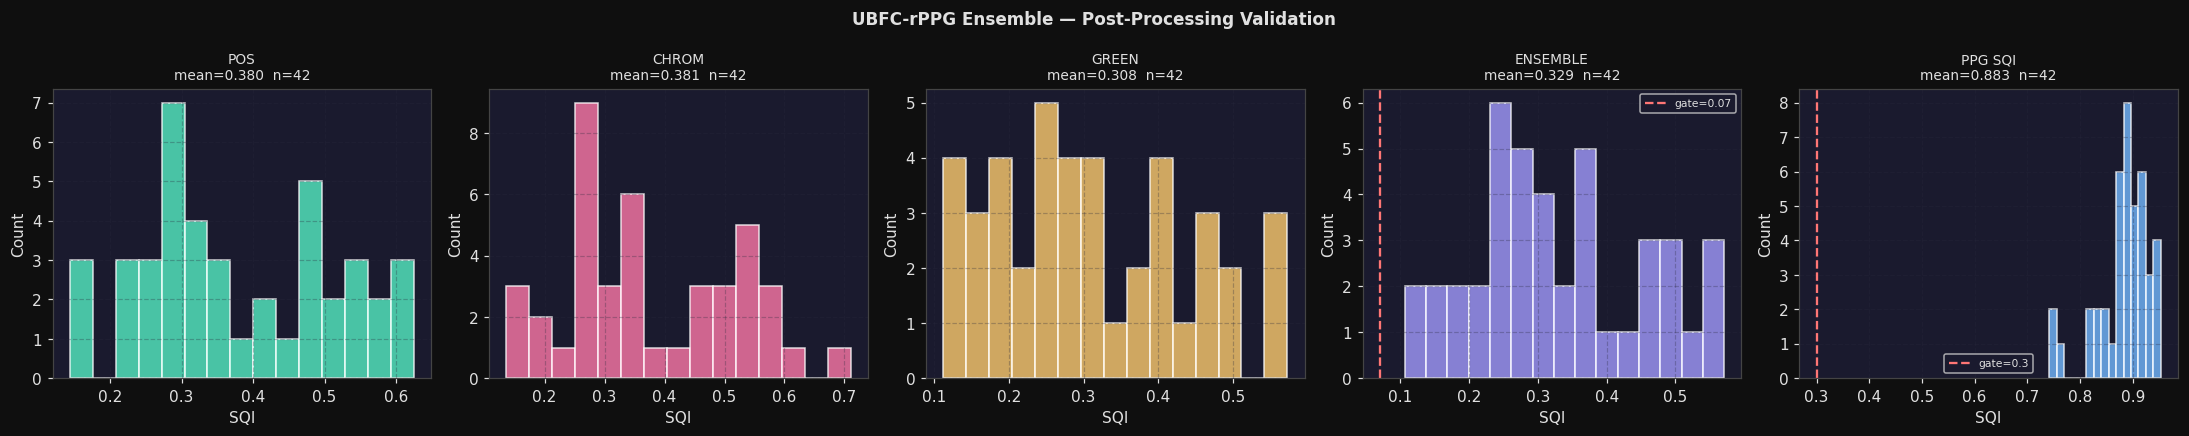

In [13]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Post-processing validation for ubfc_rppg_ensemble.h5.

    Checks:
    - Metadata completeness
    - Signal shape consistency (all datasets same T per subject)
    - Ensemble weight sum = 1.0
    - HR physiological range
    - SQI distributions with gate thresholds
    - Subject coverage vs 42 expected
    - HRV label sanity (RMSSD range, sentinel -1.0 count)
    - FPS consistency (flag ~23 fps subjects)
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print()
        print("Metadata:")
        for key, val in h5["metadata"].attrs.items():
            print(f"{key} : {val}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            rec_path = f"subjects/{subj_key}/recordings/{SESSION_ID}"
            if rec_path not in h5:
                continue
            grp = h5[rec_path]
            attrs = dict(grp.attrs)

            # Signal shape consistency
            T = grp["rppg_ensemble"].shape[0]
            for ds in ["rppg_pos", "rppg_chrom", "rppg_green", "reference_signal", "hr_continuous"]:
                assert grp[ds].shape[0] == T, f"{ds} length mismatch in {subj_key}: {grp[ds].shape[0]} vs {T}"

            # Ensemble weights sum check
            weights = grp["ensemble_weights"][:]
            w_sum = float(weights.sum())
            assert abs(w_sum - 1.0) < 1e-4, \
                f"{subj_key}: ensemble weights sum={w_sum:.4f} (expected 1.0)"

            records.append({
                "subject" : subj_key,
                "n_frames" : T,
                "fps" : attrs.get("fps"),
                "hr_mean" : attrs.get("hr_mean"),
                "rmssd_ms" : attrs.get("rmssd_ms"),
                "sdnn_ms" : attrs.get("sdnn_ms"),
                "ppg_sqi" : attrs.get("ppg_sqi"),
                "sqi_pos" : attrs.get("sqi_pos"),
                "sqi_chrom" : attrs.get("sqi_chrom"),
                "sqi_green" : attrs.get("sqi_green"),
                "sqi_ensemble" : attrs.get("sqi_ensemble"),
                "w_pos" : float(weights[0]),
                "w_chrom" : float(weights[1]),
                "w_green" : float(weights[2]),
                "no_face_pct" : attrs.get("no_face_pct"),
                "n_beats" : grp["rr_intervals"].shape[0],
                "reference_type" : attrs.get("reference_type"),
            })

    df = pd.DataFrame(records)

    print("=" * 60)
    print(f"Subject coverage : {len(df)} / 42 expected")
    missing = 42 - len(df)
    if missing > 0:
        print(f"[WARN] {missing} subjects missing — check skip reasons in log")
    print()

    # HR range
    print("HR distribution:")
    print(f"range : {df['hr_mean'].min():.1f} - {df['hr_mean'].max():.1f} BPM")
    print(f"mean : {df['hr_mean'].mean():.1f} BPM")
    implausible = df[(df["hr_mean"] < 40) | (df["hr_mean"] > 200)]
    if len(implausible):
        print(f"[WARN] {len(implausible)} implausible HR values:")
        print(implausible[["subject", "hr_mean"]].to_string(index=False))
    print()

    # n_frames range
    print("n_frames distribution:")
    print(f"range : {df['n_frames'].min()} - {df['n_frames'].max()}")
    print(f"mean : {df['n_frames'].mean():.0f}")
    print()

    # FPS — flag ~23 fps subjects
    fps_low = df[df["fps"] < 25]
    print(f"FPS distribution : {df['fps'].min():.2f} – {df['fps'].max():.2f} Hz")
    if len(fps_low):
        print(f"~23 fps subjects  : {fps_low['subject'].tolist()} (resampling was applied in pipeline)")
    print()

    # SQI distributions
    print("SQI distributions:")
    for col, label, gate in [
        ("sqi_pos", "POS", None),
        ("sqi_chrom", "CHROM", None),
        ("sqi_green", "GREEN", None),
        ("sqi_ensemble", "ENSEMBLE", RPPG_SQI_THRESHOLD),
        ("ppg_sqi", "PPG SQI", PPG_SQI_THRESHOLD),
    ]:
        s = df[col].dropna()
        gate_str = f"gate={gate} below_gate={( s < gate).sum()}" if gate else ""
        print(f"{label:<12}: mean={s.mean():.3f}  "
              f"min={s.min():.3f} max={s.max():.3f}{gate_str}")
    print()

    # Ensemble weight distribution
    print("Ensemble weights (mean across subjects):")
    for alg, col in zip(ALGORITHMS, ["w_pos", "w_chrom", "w_green"]):
        w = df[col].dropna()
        print(f"{alg:<8}: mean={w.mean():.3f} std={w.std():.3f}  min={w.min():.3f}  max={w.max():.3f}")
    print()

    # HRV label sanity
    print("HRV label sanity:")
    sentinel_rmssd = (df["rmssd_ms"] == -1.0).sum()
    print(f"RMSSD range : {df['rmssd_ms'].replace(-1.0, np.nan).dropna().min():.1f} - {df['rmssd_ms'].replace(-1.0, np.nan).dropna().max():.1f} ms")
    print(f"Sentinel -1.0: {sentinel_rmssd} subjects")
    print()

    # no_face outliers
    bad_face = df[df["no_face_pct"] > 1.0].sort_values("no_face_pct", ascending=False)
    if len(bad_face):
        print(f"no_face > 1% ({len(bad_face)} subjects):")
        print(bad_face[["subject", "no_face_pct", "n_frames"]].to_string(index=False))
    else:
        print("no_face outliers : none")
    print()

    
    # Plot - SQI distributions

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle("UBFC-rPPG Ensemble — Post-Processing Validation",
                 fontsize=11, fontweight="bold")

    plot_data = [
        ("sqi_pos", "POS", "#55efc4", None),
        ("sqi_chrom", "CHROM", "#fd79a8", None),
        ("sqi_green", "GREEN", "#fdcb6e", None),
        ("sqi_ensemble","ENSEMBLE", "#a29bfe", RPPG_SQI_THRESHOLD),
        ("ppg_sqi", "PPG SQI", "#74b9ff", PPG_SQI_THRESHOLD),
    ]
    for ax, (col, label, color, gate) in zip(axes, plot_data):
        s = df[col].dropna()
        ax.hist(s, bins=15, color=color, alpha=0.8, edgecolor="white")
        if gate is not None:
            ax.axvline(gate, color="#ff7675", ls="--", lw=1.5, label=f"gate={gate}")
            ax.legend(fontsize=7)
        ax.set_title(f"{label}\nmean={s.mean():.3f}  n={len(s)}", fontsize=9)
        ax.set_xlabel("SQI")
        ax.set_ylabel("Count")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ubfc_rppg_validation.png"), dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    return df

df_validation = validate_hdf5(HDF5_PATH)